# Kinetic proofreading, worked through StatesAndRates

Hopfield's mechanism (*PNAS* **71**, 4135, 1974) as he wrote it: four
states, five transitions, and the accuracy of the enzyme read straight
off the graph.

The puzzle it answers. An enzyme tells a right substrate from a wrong
one by binding energy, and binding energy can only buy so much. If the
wrong substrate falls off $f$ times faster, then at equilibrium the
enzyme incorporates it at $1/f$ the rate — one factor of $f$, and no
more, however the rest of the mechanism is arranged. Yet the ribosome
and DNA polymerase are far more accurate than their binding energies
allow.

Hopfield's answer is to check twice. Insert an intermediate that the
substrate can also be rejected from, reached by a step that is driven
hard enough to be one-way. Each substrate then has to survive two
independent tests, and the error falls to $1/f^2$.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import statesandrates as sr

plt.rcParams.update(
    {
        "figure.figsize": (5, 3.2),
        "figure.dpi": 130,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

MISMATCH = 100.0  # f: the wrong substrate falls off this much faster

## 1. The mechanism, as Hopfield wrote it

His Eq. 9, with the four steps numbered as in the paper:

$$C + c \;\underset{k_C}{\overset{k_C}{\rightleftharpoons}}\; Cc
\;\overset{m'}{\longrightarrow}\; Cc^*
\;\overset{W}{\longrightarrow}\; \text{product},
\qquad Cc^* \overset{l_C}{\longrightarrow} C + c$$

| step | transition | rate | discriminates |
| --- | --- | --- | --- |
| 1 | free → bound | $k_\mathrm{on}$ | no |
| 1 | bound → free | $k_\mathrm{off}$ | **yes**, $\times f$ |
| 2 | bound → activated | $m'$ | no |
| 3 | activated → free | $l_C$ | **yes**, $\times f$ |
| 4 | activated → product | $W$ | no |

Five transitions, and every feature of the argument is in them.

**Steps 2, 3 and 4 are one-way.** That is the idealization the
mechanism rests on. Because activation cannot run backwards, the
activated complex is reachable *only* through the first checkpoint, so
the two tests are independent. Section 6 puts the reverse steps back and
shows what that assumption costs in free energy — but nothing before
then needs them.

**The discrimination is in exactly two places**, the two escape routes.
Association, activation and catalysis are identical for both
substrates. Written as a `Scheme` that is structure rather than a
comment, since the mismatch multiplies two named rate constants and
nothing else.

Scheme(states=('free', 'bound', 'activated', 'product'), transitions=5) 
rates to supply: ('W', 'k_off', 'k_on', 'l', 'm')


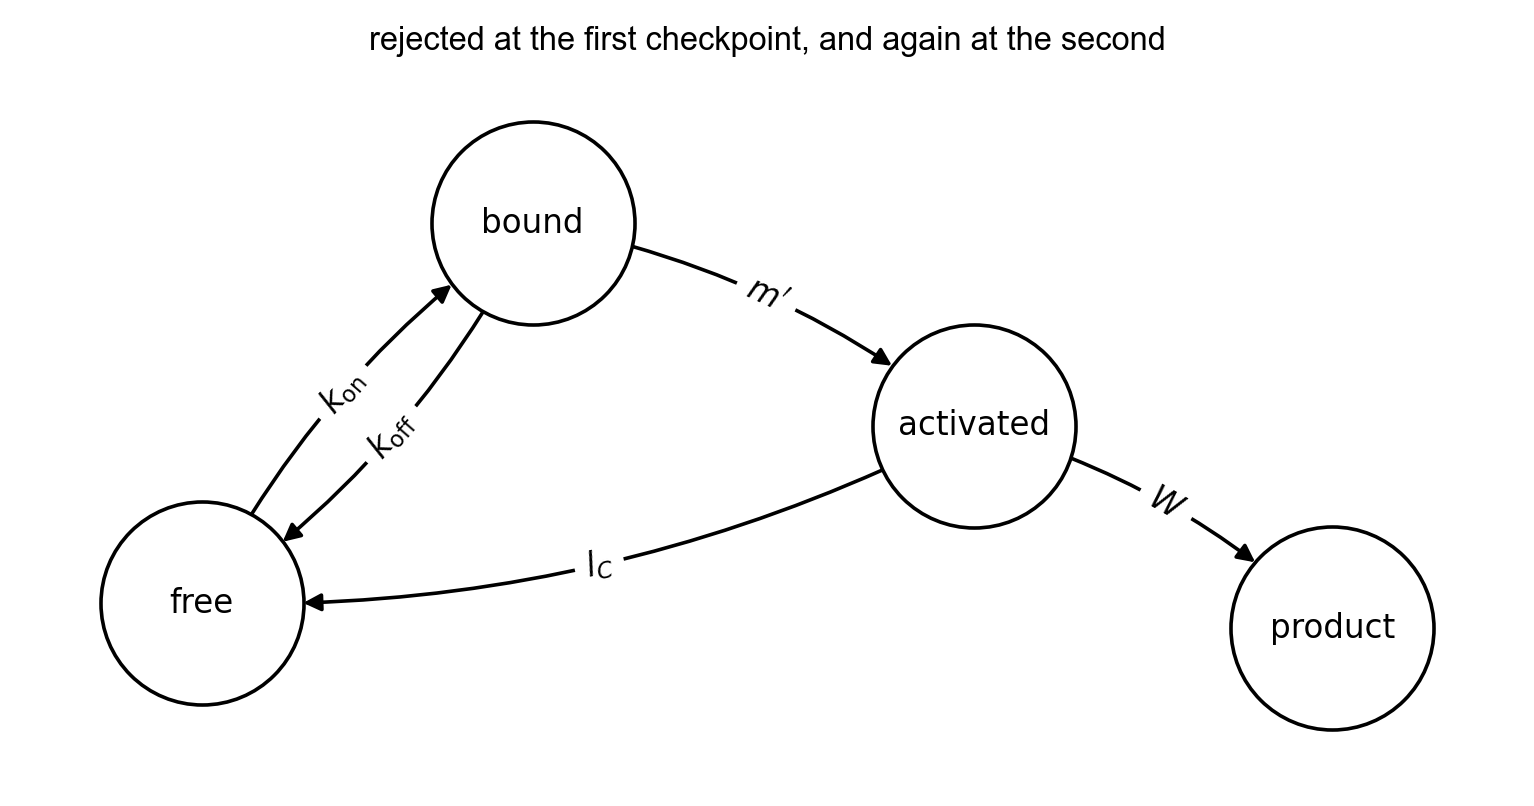

In [2]:
HOPFIELD = sr.Scheme(
    {
        ("free", "bound"): "k_on",
        ("bound", "free"): "k_off",
        ("bound", "activated"): "m",
        ("activated", "free"): "l",
        ("activated", "product"): "W",
    },
    latex={
        "k_on": r"$k_\mathrm{on}$",
        "k_off": r"$k_\mathrm{off}$",
        "m": "$m'$",
        "l": "$l_C$",
        "W": "$W$",
    },
)
# Placed by hand so that the free -> activated transition added in
# section 6 does not run through the bound state
LAYOUT = {
    "free": (0.0, 0.1),
    "bound": (1.2, 1.6),
    "activated": (2.8, 0.8),
    "product": (4.1, 0.0),
}
RATES = {"k_on": 1.0, "k_off": 1.0, "m": 0.1, "l": 1.0, "W": 0.1}


def enzyme(mismatch: float = 1.0, **overrides: float) -> sr.Graph:
    """Graph for one substrate; a mismatch of one is the right one."""
    values = dict(RATES, **overrides)
    values["k_off"] = values["k_off"] * mismatch
    values["l"] = values["l"] * mismatch
    return HOPFIELD.graph(values)


print(HOPFIELD, "\nrates to supply:", HOPFIELD.names)

fig, ax = plt.subplots(figsize=(6.0, 3.2))
sr.state_diagram(HOPFIELD, LAYOUT, ax=ax, curvature=0.13, font_size=9)
ax.set_title(
    "rejected at the first checkpoint, and again at the second", fontsize=9
)
fig.tight_layout()
plt.show()

## 2. The error is a product of two branch probabilities

The readout is the fate of one substrate that has just bound. Take *free*
and *product* as endpoints and ask which is reached first from *bound*:
that is the chance a binding event ends in product rather than release,
and `absorption_probabilities` gives it as a linear solve.

For this graph the answer is transparent enough to write down. A bound
substrate survives the first checkpoint with probability
$m'/(m' + k_\mathrm{off})$ and the second with $W/(W + l_C)$, and
because activation is one-way the two are independent, so the yield is
their product. The graph agrees to the last bit.

Both factors carry $f$ for the wrong substrate, so the error is the
product of two factors of $1/f$ — which is the whole mechanism in one
line. With these rates it comes out at $f^{-1.96}$.

In [3]:
def yield_per_binding(mismatch: float = 1.0, **overrides: float) -> float:
    """Chance that a substrate, once bound, ends as product."""
    graph = enzyme(mismatch, **overrides)
    reached = np.asarray(
        sr.absorption_probabilities(graph, ["free", "product"])
    )
    return float(reached[graph.index("bound"), graph.index("product")])


def two_branches(mismatch: float = 1.0, **overrides: float) -> float:
    """The same thing by hand: survive checkpoint one, then two."""
    values = dict(RATES, **overrides)
    escape = values["k_off"] * mismatch
    reject = values["l"] * mismatch
    first = values["m"] / (values["m"] + escape)
    second = values["W"] / (values["W"] + reject)
    return first * second


def power(value: float) -> float:
    """An error expressed as a power of the mismatch factor."""
    return np.log(value) / np.log(1 / MISMATCH)


print("substrate      yield (graph)    yield (two branches)   difference")
for mismatch, name in ((1.0, "right"), (MISMATCH, "wrong")):
    graph_says = yield_per_binding(mismatch)
    by_hand = two_branches(mismatch)
    print(
        f"{name:>9}   {graph_says:.8e}    {by_hand:.8e}"
        f"    {abs(graph_says / by_hand - 1):.1e}"
    )

error = yield_per_binding(MISMATCH) / yield_per_binding(1.0)
print(
    f"\nf = {MISMATCH:g}, so equilibrium alone would allow {1 / MISMATCH:.1e}"
)
print(f"error = {error:.4e}, which is f^-{power(error):.4f}")

substrate      yield (graph)    yield (two branches)   difference


W0909 21:21:02.044341 3634358 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


    right   8.26446281e-03    8.26446281e-03    2.2e-16
    wrong   9.98002996e-07    9.98002996e-07    8.9e-16

f = 100, so equilibrium alone would allow 1.0e-02
error = 1.2076e-04, which is f^-1.9590


## 3. Accuracy is paid for in turnover

The second checkpoint only works if a substrate that reaches the
activated complex is far more likely to be rejected than turned over —
otherwise the test is never applied. The first works only if activation
is slow compared with dissociation. Both are the same trade: the enzyme
improves by discarding more of what it binds.

Driving $m'$ and $W$ down together takes the accuracy from $f^{1.70}$ to
$f^{2.00}$ while the yield per binding event falls through five orders of
magnitude. Perfect proofreading is an enzyme that does essentially
nothing, and $1/f^2$ is a limit approached rather than reached.

In [4]:
PACE = np.geomspace(1.0, 1e-3, 25)
accuracy = np.array(
    [
        power(
            yield_per_binding(MISMATCH, m=p, W=p)
            / yield_per_binding(1.0, m=p, W=p)
        )
        for p in PACE
    ]
)
yields = np.array([yield_per_binding(1.0, m=p, W=p) for p in PACE])

print("  m' = W    yield per binding   accuracy (powers of f)")
for i in range(0, len(PACE), 4):
    print(f"{PACE[i]:9.4f}   {yields[i]:17.4e}   {accuracy[i]:16.4f}")

  m' = W    yield per binding   accuracy (powers of f)
   1.0000          2.5000e-01             1.7033
   0.3162          5.7722e-02             1.8820
   0.1000          8.2645e-03             1.9590
   0.0316          9.3963e-04             1.9866
   0.0100          9.8030e-05             1.9957
   0.0032          9.9371e-06             1.9986
   0.0010          9.9800e-07             1.9996


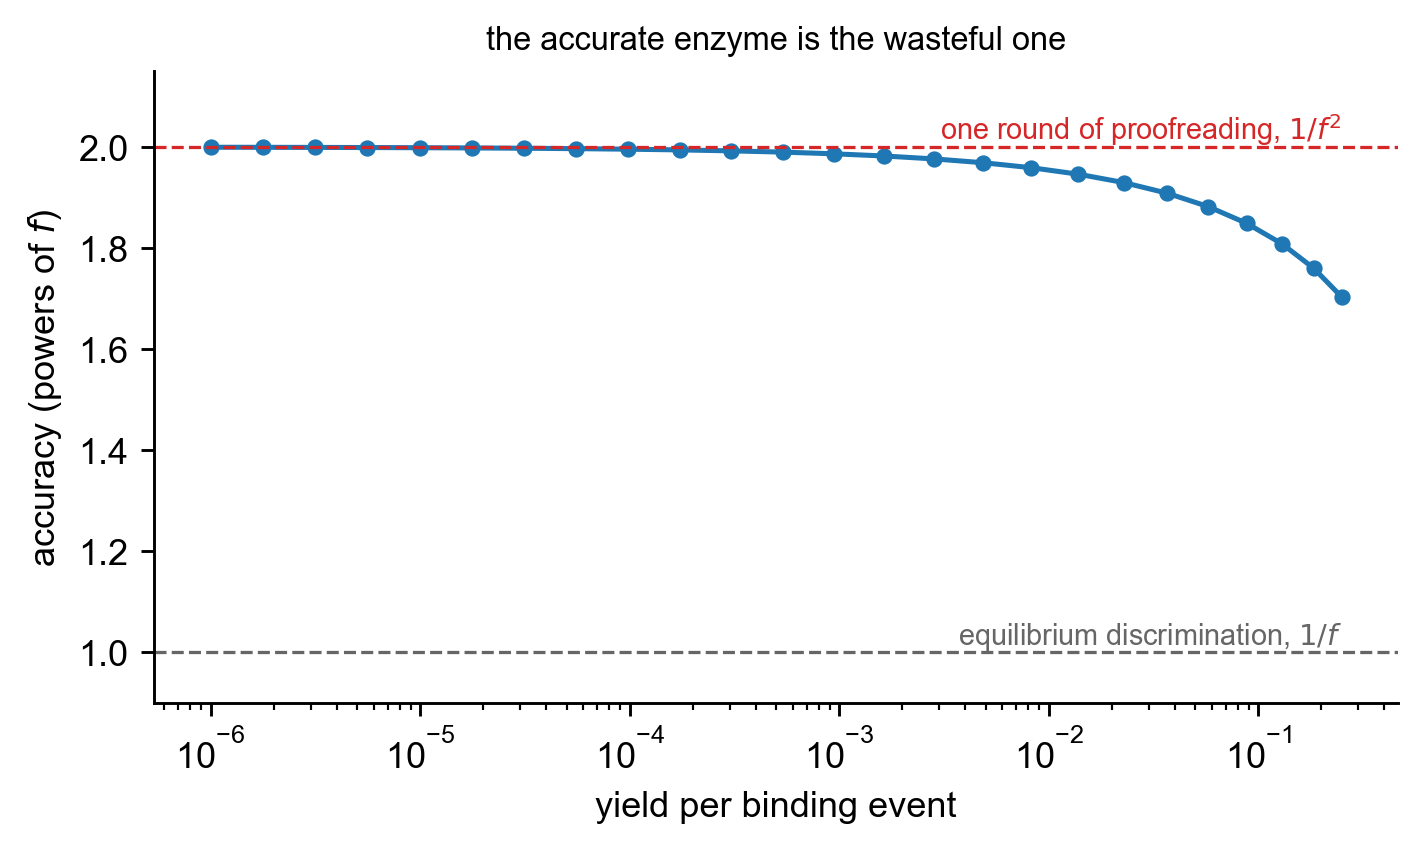

In [5]:
fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.plot(yields, accuracy, "o-", ms=3.5, lw=1.4, color="tab:blue")
for level, label, color in (
    (1.0, "equilibrium discrimination, $1/f$", "0.4"),
    (2.0, "one round of proofreading, $1/f^2$", "tab:red"),
):
    ax.axhline(level, ls="--", lw=0.9, color=color)
    ax.annotate(
        label,
        (yields.max(), level),
        ha="right",
        va="bottom",
        fontsize=8,
        color=color,
    )
ax.set(
    xscale="log",
    xlabel="yield per binding event",
    ylabel="accuracy (powers of $f$)",
    ylim=(0.9, 2.15),
    title="the accurate enzyme is the wasteful one",
)
ax.title.set_size(9)
fig.tight_layout()
plt.show()

## 4. More checkpoints

Nothing stops the mechanism from checking three or four times: put
several activated complexes in series, each with its own one-way
rejection route. Building that is a loop over stages, since a `Scheme`
is a mapping from transitions to names.

Each stage adds exactly one power of $f$ — 1.96, 2.94, 3.92, 4.90 — and
costs a factor of about eleven in yield. Nothing has to be tuned to make
this work, because one-way activation closes every shortcut by
construction. That the same table needed a driving parameter and
30 kcal/mol to get three stages working is the subject of section 6.

In [6]:
def ladder(stages: int, mismatch: float = 1.0, **overrides: float) -> float:
    """Hopfield's scheme with several activated complexes in series."""
    values = dict(RATES, **overrides)
    values["k_off"] = values["k_off"] * mismatch
    values["l"] = values["l"] * mismatch
    chain = ["bound"] + [f"activated{i + 1}" for i in range(stages)]
    symbols = {("free", "bound"): "k_on", ("bound", "free"): "k_off"}
    for source, target in zip(chain, chain[1:]):
        symbols[(source, target)] = "m"
        symbols[(target, "free")] = "l"
    symbols[(chain[-1], "product")] = "W"
    graph = sr.Scheme(symbols).graph(values)
    reached = np.asarray(
        sr.absorption_probabilities(graph, ["free", "product"])
    )
    return float(reached[graph.index("bound"), graph.index("product")])


print("stages   transitions   yield        error        accuracy")
for stages in (1, 2, 3, 4):
    value = ladder(stages, MISMATCH) / ladder(stages, 1.0)
    print(
        f"   {stages}         {2 * stages + 3:2d}      {ladder(stages, 1.0):.3e}"
        f"    {value:.4e}    {power(value):8.4f}"
    )

stages   transitions   yield        error        accuracy
   1          5      8.264e-03    1.2076e-04      1.9590


   2          7      7.513e-04    1.3270e-06      2.9386


   3          9      6.830e-05    1.4583e-08      3.9181


   4         11      6.209e-06    1.6025e-10      4.8976


## 5. Counting individual substrates

Removing step 1's forward direction makes *free* an endpoint too, which
turns the mechanism into a single attempt: a substrate starts bound and
ends either released or turned over. `simulate` then just counts.

The right substrate makes product in 8 of every thousand attempts, which
400 000 simulated complexes measure to two figures. The wrong one is
expected to make product 0.4 times in 400 000, and makes it zero times.
The discrimination is real, but a simulation is the wrong instrument for
a rate this small — which is what the exact linear solve above is for.

In [7]:
ONE_ATTEMPT = sr.Scheme(
    {
        edge: name
        for edge, name in HOPFIELD.symbols.items()
        if edge != ("free", "bound")
    },
    latex={
        name: HOPFIELD.latex[name] for name in HOPFIELD.names if name != "k_on"
    },
)
MOLECULES = 400_000

for name, mismatch in (("right", 1.0), ("wrong", MISMATCH)):
    values = dict(RATES)
    values["k_off"] = values["k_off"] * mismatch
    values["l"] = values["l"] * mismatch
    graph = ONE_ATTEMPT.graph({k: v for k, v in values.items() if k != "k_on"})
    trace = sr.simulate(graph, {"bound": MOLECULES}, 500.0, seed=0)
    made = int((trace.targets == graph.index("product")).sum())
    exact = yield_per_binding(mismatch)
    print(
        f"{name:>5}: {made:6d} products from {MOLECULES}"
        f"  ->  {made / MOLECULES:.4e}   exact {exact:.4e}"
        f"   expected count {exact * MOLECULES:.1f}"
    )

right:   3334 products from 400000  ->  8.3350e-03   exact 8.2645e-03   expected count 3305.8


wrong:      0 products from 400000  ->  0.0000e+00   exact 9.9800e-07   expected count 0.4


## 6. What the one-way steps cost

Everything so far took steps 2, 3 and 4 to be strictly irreversible, and
the package will not let that assumption pass quietly. `cycle_affinity`
returns **infinity** for the cycle through the activated complex: a
transition with no reverse is an infinite driving force.
`is_detailed_balanced` is false, and `equilibrium` returns `nan`, because
an absorbing product state leaves the graph reducible and its stationary
distribution is not unique.

To ask what the driving actually costs, the reverse steps have to go
back in — and now the three extra transitions earn their place. Reverse
activation $m'$, re-association into the activated complex, and product
release, each written at its *equilibrium* value and then divided by a
driving factor. A factor of one means no driving at all.

That gives Hopfield's central result. With no driving the accuracy is
$f^{0.98}$: proofreading buys nothing, because the activated complex can
now be reached directly, without passing the first checkpoint. As the
drive closes that shortcut the error falls — most of the gap is shut by
10 kcal/mol, and it saturates just short of $1/f^2$ by about
14 kcal/mol, close to the free energy of one ATP hydrolysis.

Every extra checkpoint needs roughly 8 kcal/mol more — one saturates by
14, two by 22, three by 30 — which is the cost of accuracy in the
currency a cell actually pays: about one hydrolysis per checkpoint, per
attempt. And a cascade that is not paid for is worse than none: three
checkpoints at 14 kcal/mol give $f^{1.92}$, below what a single
checkpoint manages, because every extra intermediate is one more state
the shortcut can reach directly, bypassing everything upstream of it.

In [8]:
graph = enzyme()
print(
    "affinity of free -> bound -> activated:"
    f" {sr.cycle_affinity(graph, ['free', 'bound', 'activated'])} kcal/mol"
)
print(f"detailed balanced: {sr.is_detailed_balanced(graph)}")
print(f"equilibrium: {np.asarray(sr.equilibrium(graph))}")

# The same mechanism with every step reversible, so a finite drive can
# be written down.  Reverse rates are at their equilibrium values and
# the drive divides them.
ADDED = {
    ("activated", "bound"): "m_rev",
    ("free", "activated"): "k_on_2",
    ("product", "free"): "k_rel",
}
REVERSIBLE = sr.Scheme(
    dict(HOPFIELD.symbols) | ADDED,
    latex=dict(HOPFIELD.latex)
    | {
        "m_rev": r"$m'_\mathrm{rev}$",
        "k_on_2": r"$k_\mathrm{on}'$",
        "k_rel": r"$k_\mathrm{rel}$",
    },
)
POISED = dict(RATES) | {"m_rev": 0.1, "k_on_2": 1.0, "k_rel": 1e3}

affinity of free -> bound -> activated: inf kcal/mol
detailed balanced: False


equilibrium: [nan nan nan nan]


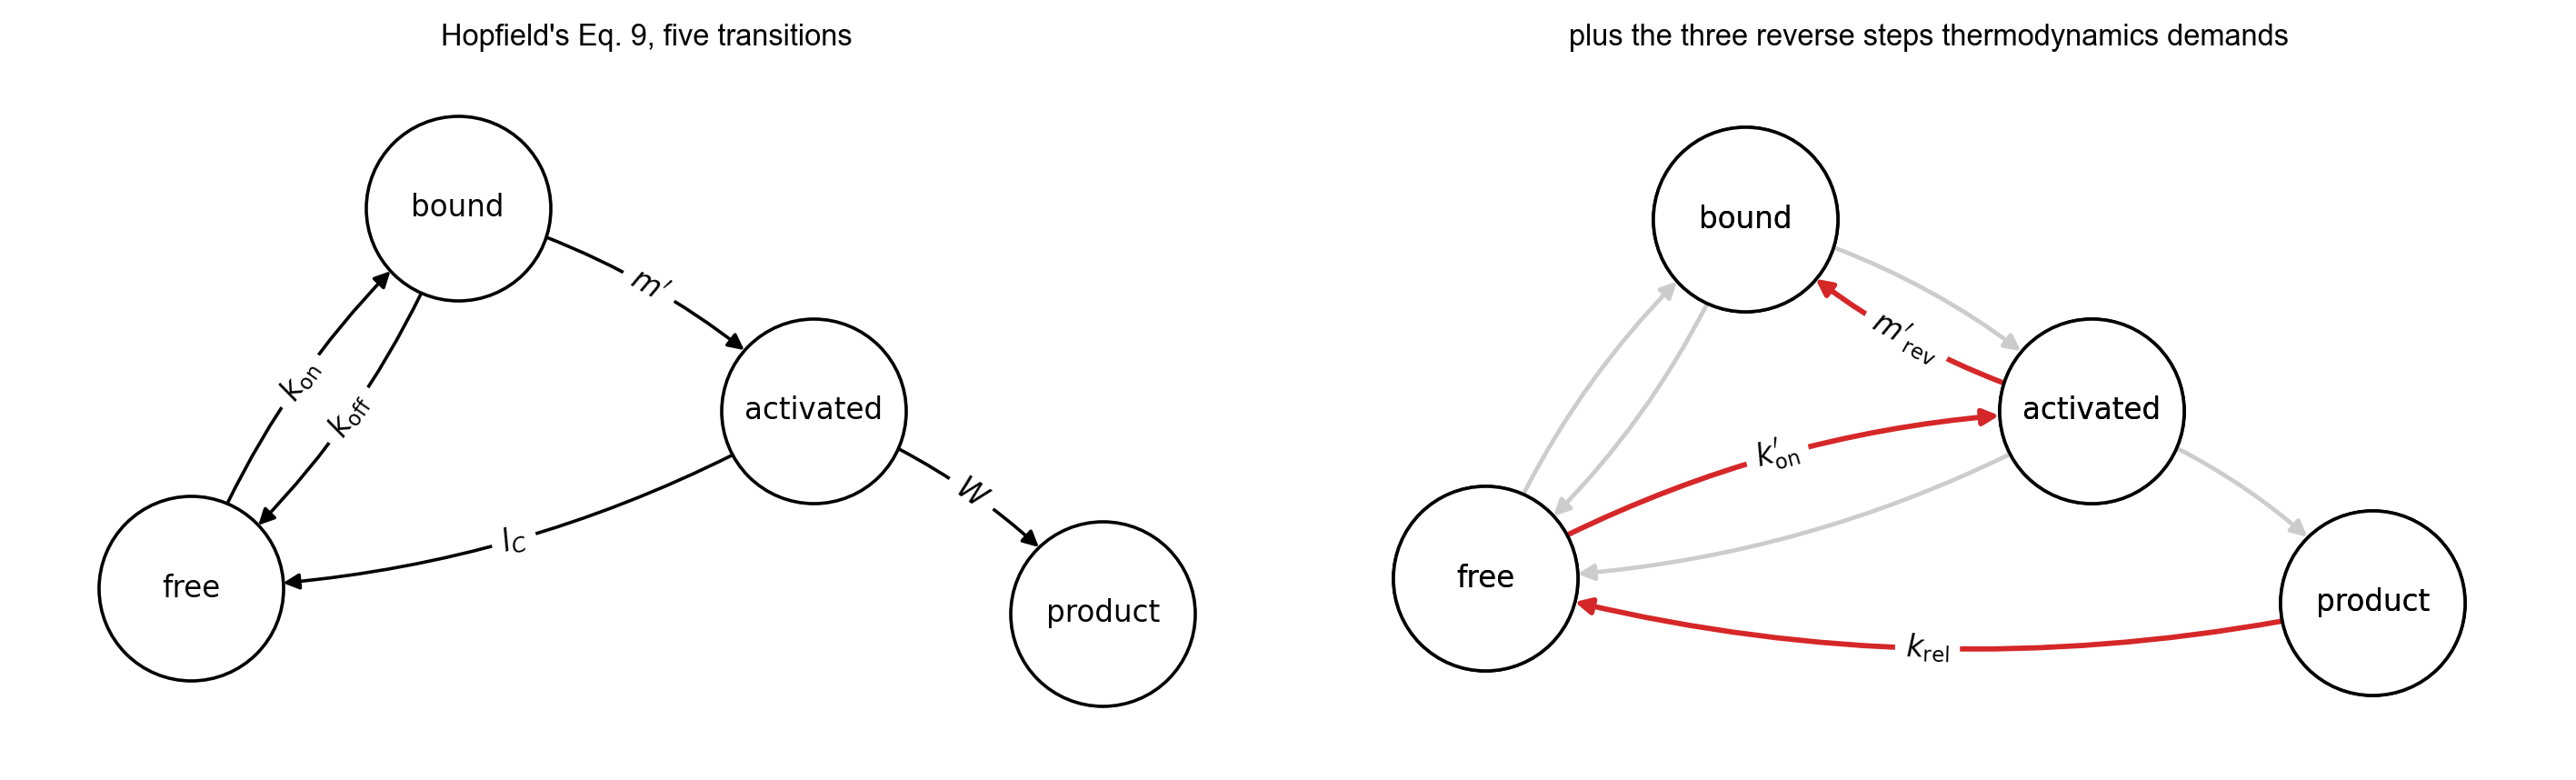

In [9]:
# Drawing the full graph unlabelled and then the three added transitions
# on the same layout leaves only the additions named
JUST_ADDED = sr.Scheme(
    ADDED,
    states=REVERSIBLE.states,
    latex={name: REVERSIBLE.latex[name] for name in ADDED.values()},
)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.4))
sr.state_diagram(HOPFIELD, LAYOUT, ax=axes[0], curvature=0.13, font_size=9)
axes[0].set_title("Hopfield's Eq. 9, five transitions", fontsize=9)
sr.state_diagram(
    REVERSIBLE,
    LAYOUT,
    ax=axes[1],
    curvature=0.13,
    font_size=9,
    rate_labels=False,
    edge_color="0.8",
    width=1.3,
)
sr.state_diagram(
    JUST_ADDED,
    LAYOUT,
    ax=axes[1],
    curvature=0.13,
    font_size=9,
    edge_color="tab:red",
    width=1.6,
)
axes[1].set_title(
    "plus the three reverse steps thermodynamics demands", fontsize=9
)
fig.tight_layout()
plt.show()

In [10]:
def driven(
    mismatch: float = 1.0, drive: float = 1e5, **overrides: float
) -> sr.Graph:
    values = dict(POISED, **overrides)
    values["k_off"] = values["k_off"] * mismatch
    values["l"] = values["l"] * mismatch
    values["m_rev"] = values["m_rev"] / drive
    values["k_on_2"] = values["k_on_2"] / drive
    return REVERSIBLE.graph(values)


def per_free_enzyme(graph: sr.Graph) -> float:
    """Products per second, per unit of free enzyme."""
    net = sr.fluxes(graph)
    made = net[graph.index("activated"), graph.index("product")]
    return float(made / sr.equilibrium(graph)[graph.index("free")])


def driven_error(**kwargs: float) -> float:
    wrong = per_free_enzyme(driven(MISMATCH, **kwargs))
    return wrong / per_free_enzyme(driven(1.0, **kwargs))


DRIVES = np.geomspace(1.0, 1e8, 40)
affinity = np.array(
    [
        sr.cycle_affinity(driven(drive=d), ["free", "bound", "activated"])
        for d in DRIVES
    ]
)
errors = np.array([driven_error(drive=d) for d in DRIVES])
print("\n  drive   affinity   error        accuracy")
for d, a, e in list(zip(DRIVES, affinity, errors))[::6]:
    print(f"{d:8.1e}  {a:7.3f}   {e:.4e}   {power(e):8.4f}")


def driven_ladder(
    stages: int, mismatch: float = 1.0, drive: float = 1e5
) -> float:
    """A reversible ladder, so each stage has a shortcut to close."""
    chain = ["bound"] + [f"activated{i + 1}" for i in range(stages)]
    symbols = {("free", "bound"): "k_on", ("bound", "free"): "k_off"}
    for source, target in zip(chain, chain[1:]):
        symbols[(source, target)] = "m"
        symbols[(target, source)] = "m_rev"
        symbols[(target, "free")] = "l"
        symbols[("free", target)] = "k_on_2"
    symbols[(chain[-1], "product")] = "W"
    symbols[("product", "free")] = "k_rel"
    values = dict(POISED)
    values["k_off"] = values["k_off"] * mismatch
    values["l"] = values["l"] * mismatch
    values["m_rev"] = values["m_rev"] / drive
    values["k_on_2"] = values["k_on_2"] / drive
    graph = sr.Scheme(symbols).graph(values)
    net = sr.fluxes(graph)
    made = net[graph.index(chain[-1]), graph.index("product")]
    return float(made / sr.equilibrium(graph)[graph.index("free")])


print("\nhow much driving each extra checkpoint needs")
print("stages   affinity   accuracy")
for stages in (1, 2, 3):
    for drive in (1e5, 1e8, 1e11, 1e14):
        value = driven_ladder(stages, MISMATCH, drive) / driven_ladder(
            stages, 1.0, drive
        )
        each = sr.cycle_affinity(
            driven(drive=drive), ["free", "bound", "activated"]
        )
        print(f"   {stages}      {each:7.3f}   {power(value):8.4f}")
    print()


  drive   affinity   error        accuracy
 1.0e+00    0.000   1.0906e-02     0.9812
 1.7e+01    3.358   4.4096e-03     1.1778
 2.9e+02    6.716   5.1884e-04     1.6425
 4.9e+03   10.074   1.4499e-04     1.9193
 8.4e+04   13.433   1.2219e-04     1.9565
 1.4e+06   16.791   1.2084e-04     1.9589
 2.4e+07   20.149   1.2076e-04     1.9590

how much driving each extra checkpoint needs
stages   affinity   accuracy
   1       13.642     1.9569
   1       21.828     1.9590
   1       30.013     1.9590
   1       38.199     1.9590



   2       13.642     2.4176
   2       21.828     2.9364
   2       30.013     2.9386
   2       38.199     2.9386



   3       13.642     1.9203
   3       21.828     3.3966
   3       30.013     3.9159
   3       38.199     3.9181



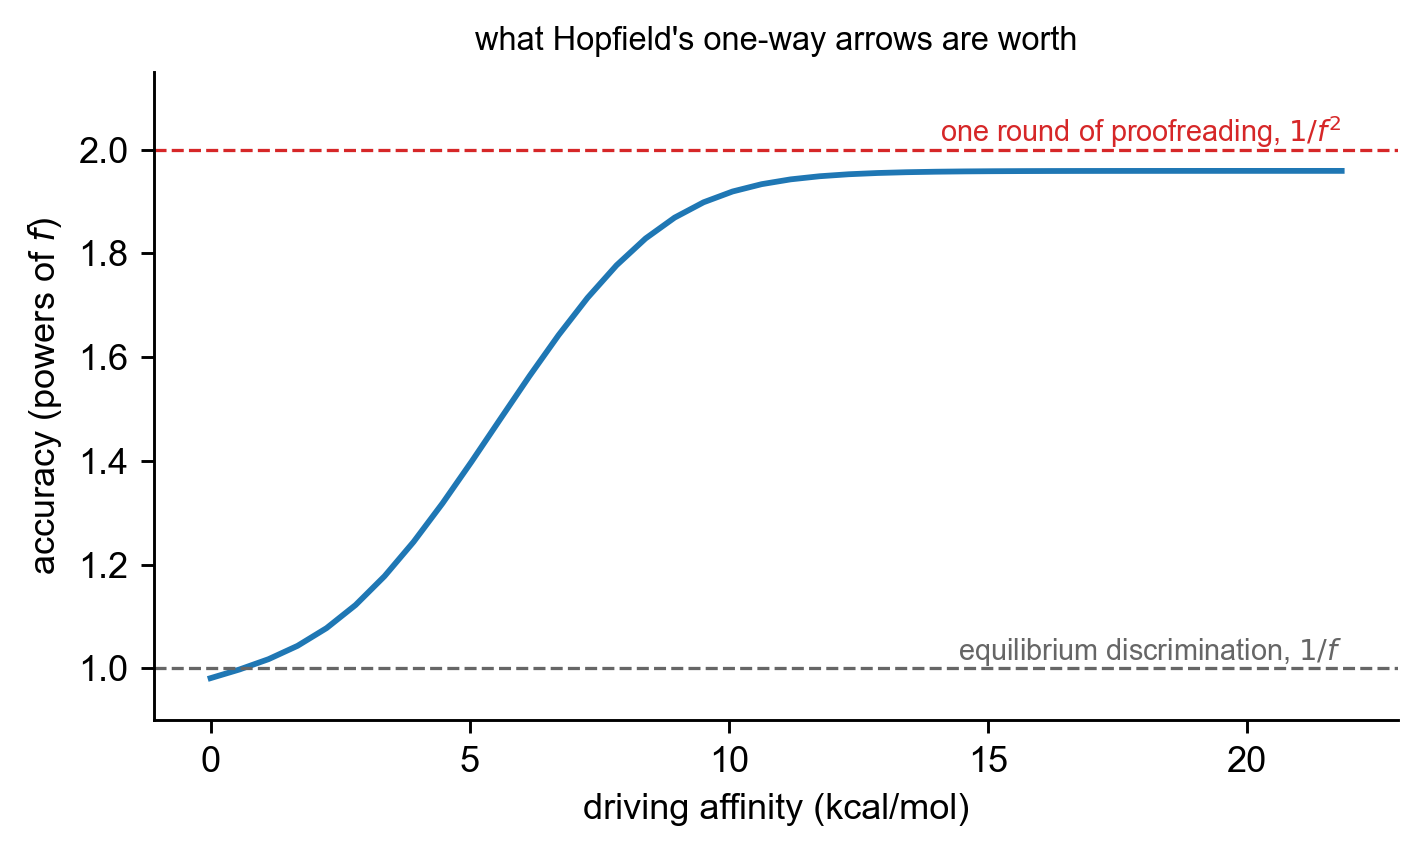

In [11]:
fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.plot(affinity, power(errors), lw=1.6, color="tab:blue")
for level, label, color in (
    (1.0, "equilibrium discrimination, $1/f$", "0.4"),
    (2.0, "one round of proofreading, $1/f^2$", "tab:red"),
):
    ax.axhline(level, ls="--", lw=0.9, color=color)
    ax.annotate(
        label,
        (affinity.max(), level),
        ha="right",
        va="bottom",
        fontsize=8,
        color=color,
    )
ax.set(
    xlabel="driving affinity (kcal/mol)",
    ylabel="accuracy (powers of $f$)",
    ylim=(0.9, 2.15),
    title="what Hopfield's one-way arrows are worth",
)
ax.title.set_size(9)
fig.tight_layout()
plt.show()

## 7. No landscape while it is running

Proofreading *requires* that detailed balance be broken — that is the
mechanism — so a proofreading enzyme never has a free energy landscape,
and the functions that would draw one refuse. This is the physics showing
through rather than a limitation of the package: a landscape assigns one
barrier to each transition, and a driven transition has two different
effective barriers depending on which way it is crossed.

In [12]:
for name, call in (
    ("barrier_energies", lambda: sr.barrier_energies(driven())),
    ("relaxation_times", lambda: sr.relaxation_times(driven())),
):
    try:
        call()
    except ValueError as failure:
        print(f"{name}: {failure}")

print("\nfree_energies still describes the occupancies, in kcal/mol:")
for mismatch, name in ((1.0, "right"), (MISMATCH, "wrong")):
    each = driven(mismatch)
    energies = np.asarray(sr.free_energies(each, reference="free"))
    print(
        f"  {name:>5}: "
        + "  ".join(
            f"{state} {energy:+6.2f}"
            for state, energy in zip(each.states, energies)
        )
    )

barrier_energies: barrier heights require detailed balance
relaxation_times: relaxation rates require detailed balance

free_energies still describes the occupancies, in kcal/mol:
  right: free  +0.00  bound  +0.06  activated  +1.48  product  +6.93
  wrong: free  +0.00  bound  +2.73  activated  +6.82  product +12.27


## Closing

Hopfield's Eq. 9 is four states and five rate constants, and it gave the
error fraction, the turnover sacrificed to get it, the scaling with the
number of checkpoints, and a count from simulated molecules — with the
accuracy falling out as a product of two branch probabilities that
`absorption_probabilities` returns exactly.

The one-way arrows are what make it that simple, and they are also what
make it thermodynamically impossible as written. Putting the reverse
steps back costs three extra transitions and buys the one thing the
minimal scheme cannot say: that the accuracy is bounded by the free
energy spent, about 8 kcal/mol per factor of $f$.

[michaelis_menten.ipynb](michaelis_menten.ipynb) works the same
turnover cycle without the competition, and covers the rate law, passage
times, transients, mutations and control coefficients.
[folding_and_binding.ipynb](folding_and_binding.ipynb) uses the same
machinery to show a double mutant cycle reporting coupling that is not
there.